In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime

import torch

DATA_PATH = "E:/ML/UBC/ColorectalHist"
print(DATA_PATH)


E:/ML/UBC/ColorectalHist


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
from sklearn.preprocessing import LabelEncoder

uniqueLabels = ["Tumor", "Stroma", "Complex", "Lympho", "Debris", "Mucosa", "Adipose", "Empty"]

enc = LabelEncoder()
enc.fit(uniqueLabels)
print(enc.classes_)
enc.transform(["Stroma"])

['Adipose' 'Complex' 'Debris' 'Empty' 'Lympho' 'Mucosa' 'Stroma' 'Tumor']


array([6])

In [4]:
allFiles = []
stopLoop = False
for root, dirs, files in os.walk(DATA_PATH, "Kather_texture_2016_image_tiles_5000", "01_TUMOR"):
    for f in files:
        if f.endswith(".tif"):
            allFiles.append(os.path.join(root, f))
    
len(allFiles)

5010

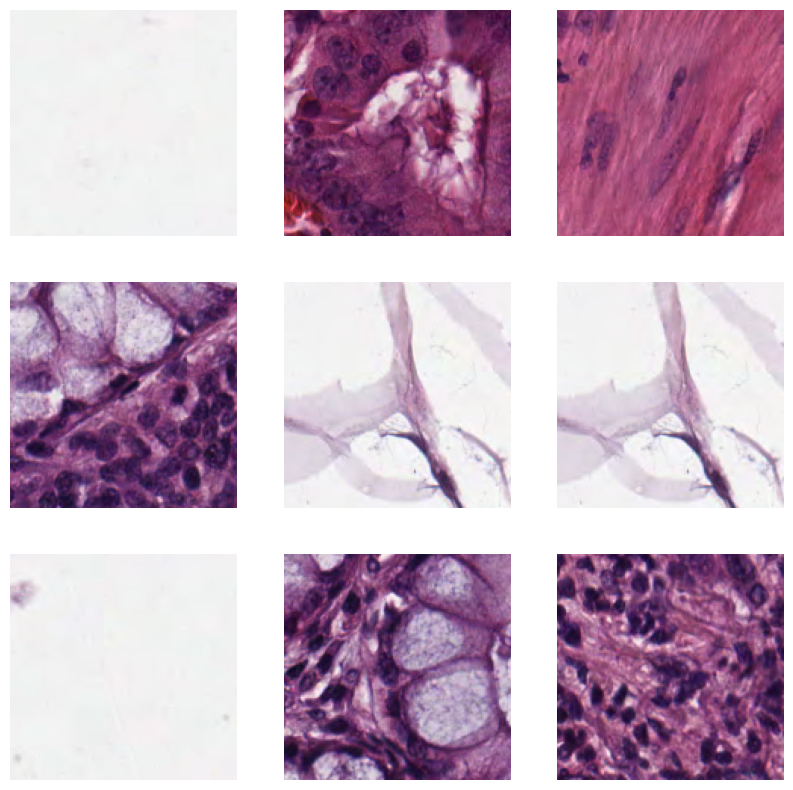

In [5]:

IMG_SIZE = (150, 150)
eps=1e-12

def readImage(path, skipResize=False):
    with Image.open(path) as data:
        
        w, h = data.width, data.height
        # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
        # medValue = np.median(data)

        #Center crop
        if w>h:
            diff = w-h
            data = data[diff//2:diff//2+h, :]
        if h>w:
            diff = h-w
            data = data[:, diff//2:diff//2+w]

        # data = data - np.min(data)
        # data = data * 1.0/(np.max(data)+eps)

        w, h = data.width, data.height

        # resize
        if not skipResize:
            if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
                data = np.array(data.resize(IMG_SIZE))
        
        return np.array(data).astype(np.float32)/255.0



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath))
    _ = plt.axis("off")
# plt.colorbar()

In [6]:
data={}
paths=[]
allImages=[]
labels=[]

for i,label in enumerate(tqdm(uniqueLabels)):
    imData = []
    for root, dirs, files in os.walk(os.path.join(DATA_PATH, "Kather_texture_2016_image_tiles_5000", "0"+str(i+1)+"_"+label.upper())):
        for f in files:
            if f.endswith(".tif"):
                x = readImage(os.path.join(root, f))
                imData.append(x)
                allImages.append(x)
                encLabel=enc.transform([label.capitalize()])[0]
                oheLabel = np.zeros(len(enc.classes_))
                oheLabel[encLabel] = 1
                labels.append(oheLabel)
                paths.append(os.path.join(root, f))
    data[label] = np.array(imData)

len(paths)

100%|██████████| 8/8 [00:03<00:00,  2.15it/s]


5000

'E:/ML/UBC/ColorectalHist\\Kather_texture_2016_image_tiles_5000\\01_TUMOR\\12F08_CRC-Prim-HE-02_007b.tif_Row_301_Col_1.tif'

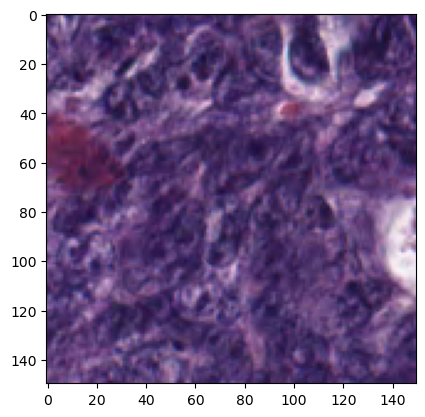

In [7]:
plt.imshow(data["Tumor"][100,:,:,:])
paths[100]
# labels[100]

In [8]:
TRAIN_TEST_SPLIT = 0.7

from sklearn.model_selection import train_test_split

allImages = np.array(allImages)
print(allImages.shape)
labels = np.array(labels)
print(labels.shape)


X_train, X_val, y_train, y_val = train_test_split( allImages, labels, test_size=1-TRAIN_TEST_SPLIT, random_state=42)
print(X_train.shape, X_val.shape)

(5000, 150, 150, 3)
(5000, 8)
(3499, 150, 150, 3) (1501, 150, 150, 3)


In [9]:
BATCH_SIZE = 32

dataset = torch.utils.data.TensorDataset(torch.Tensor(np.array(X_train)), torch.Tensor(y_train))
datasetVal = torch.utils.data.TensorDataset(torch.Tensor(np.array(X_val)), torch.Tensor(y_val))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
for X, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    # print(targets)
    break

Shape of X: torch.Size([32, 150, 150, 3]) torch.float32
Shape of target: torch.Size([32, 8]) torch.float32


tensor([0., 0., 0., 0., 1., 0., 0., 0.])


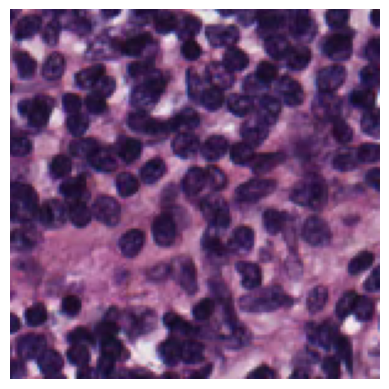

In [11]:
idx=5
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [12]:
from torch import nn
import torchinfo
from torch import nn
import torch
from modelZoo.models import Res2DModel

Dropout=0.4
HIDDEN_DIM=64
K=2

    
model = Res2DModel(len(enc.classes_), channels=3, name="Res2DModelColorectal_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM)

# print(model)

# testbatch = next(iter(trainLoader))
# testX = testbatch[0]
# yhat = model(testX)
# input_names = ['3DArray']
# output_names = ['yBowel', 'yExtra', 'yKidney', 'yLiver', 'ySpleen']
# torch.onnx.export(model, testX, 'convModel.onnx', input_names=input_names, output_names=output_names, export_params=True, )


from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                   Output Shape              Param #
Res2DModel                               [32, 8]                   --
├─Sequential: 1-1                        [32, 4, 150, 150]         --
│    └─BatchNorm2d: 2-1                  [32, 3, 150, 150]         6
│    └─LeakyReLU: 2-2                    [32, 3, 150, 150]         --
│    └─Conv2d: 2-3                       [32, 4, 150, 150]         112
├─Sequential: 1-2                        [32, 4, 150, 150]         --
│    └─BatchNorm2d: 2-4                  [32, 4, 150, 150]         8
│    └─LeakyReLU: 2-5                    [32, 4, 150, 150]         --
│    └─Conv2d: 2-6                       [32, 4, 150, 150]         148
├─Sequential: 1-3                        [32, 8, 75, 75]           --
│    └─BatchNorm2d: 2-7                  [32, 4, 150, 150]         8
│    └─LeakyReLU: 2-8                    [32, 4, 150, 150]         --
│    └─Conv2d: 2-9                       [32, 8, 75, 75]           296
├─Sequential: 1

In [13]:
# model_graph.visual_graph

In [14]:
loadExistingModel=False

if loadExistingModel:
    # model = simpleUnet(K=4)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)

    checkpoint = torch.load(os.path.join("./", "ConvLSTMModelDaily2_epoch_999.pt"), map_location=device)
    # startEpoch=136
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    startEpoch = checkpoint['epoch']
    # loss = checkpoint['loss']
    model.train()
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), 1e-3)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.998)

In [15]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter


LOG_INTERVAL=5
epochs = 100
EARLY_STOPPING_PATIENCE=10
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
lossFn = torch.nn.BCELoss()


# accMetric = tf.keras.metrics.BinaryAccuracy()
accMetric = metrics.BinaryAccuracy().to(device)
ceMetric = metrics.BinaryNormalizedEntropy().to(device)
aurocMetric = metrics.BinaryAUROC().to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

# CEMetricVal = tf.keras.metrics.BinaryCrossentropy()
# accMetricVal = tf.keras.metrics.BinaryAccuracy()
# f1MetricVal = tf.keras.metrics.F1Score(threshold=0.5, average="micro")
accMetricVal = metrics.BinaryAccuracy().to(device)


def train(dataloader, model, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        # predictions = torch.cat(pred, axis=-1)
        
        loss = lossFn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accMetric.update(torch.flatten(pred), torch.flatten(y))
        aurocMetric.update(torch.flatten(pred), torch.flatten(y))
        ceMetric.update(torch.flatten(pred), torch.flatten(y))
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, CrossEntropy: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(), ceMetric.compute().item(), aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        lossAdd = lossFn(pred, y)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(torch.flatten(pred), torch.flatten(y))
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(accMetricVal.compute()))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", accMetricVal.compute(), epoch)
    summary_writer.flush()
    return lossVal


bestValCE=99.0
bestEpoch=0


for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    ceMetric.reset()
    aurocMetric.reset()

    avgCEVal = validate(valLoader, model, t)
    accMetricVal.reset()
    
    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgCEVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgCEVal < bestValCE:
        bestValCE = avgCEVal
        bestEpoch = t
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break
print("Done!")

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


Epoch 1
-------------------------------
loss: 0.375076, acc: 0.8750, CrossEntropy: 0.9955, AUROC: 0.5328  [    0/ 3499]
loss: 0.378737, acc: 0.8750, CrossEntropy: 1.0006, AUROC: 0.5035  [  160/ 3499]
loss: 0.375069, acc: 0.8750, CrossEntropy: 0.9988, AUROC: 0.5207  [  320/ 3499]
loss: 0.373033, acc: 0.8750, CrossEntropy: 0.9980, AUROC: 0.5287  [  480/ 3499]
loss: 0.373531, acc: 0.8750, CrossEntropy: 0.9974, AUROC: 0.5343  [  640/ 3499]
loss: 0.376354, acc: 0.8750, CrossEntropy: 0.9959, AUROC: 0.5446  [  800/ 3499]
loss: 0.372652, acc: 0.8750, CrossEntropy: 0.9944, AUROC: 0.5572  [  960/ 3499]
loss: 0.368861, acc: 0.8750, CrossEntropy: 0.9921, AUROC: 0.5746  [ 1120/ 3499]
loss: 0.365118, acc: 0.8750, CrossEntropy: 0.9898, AUROC: 0.5904  [ 1280/ 3499]
loss: 0.359669, acc: 0.8750, CrossEntropy: 0.9868, AUROC: 0.6029  [ 1440/ 3499]
loss: 0.371412, acc: 0.8750, CrossEntropy: 0.9844, AUROC: 0.6133  [ 1600/ 3499]
loss: 0.347119, acc: 0.8751, CrossEntropy: 0.9799, AUROC: 0.6240  [ 1760/ 3499]


In [16]:
torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", model.name+"_epoch_{}.pt".format(t)))

In [20]:
# torch.save(model.state_dict, os.path.join(DATA_PATH, "convModel.pt"))

# model_scripted = torch.jit.script(model) # Export to TorchScript
# model_scripted.save('model_scripted.pt') # Save